In [1]:
import mne
from mne.preprocessing import ICA
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from scipy.signal import convolve
from scipy.ndimage import convolve1d
import seaborn as sns

In [2]:
subject1 = sc.io.loadmat("../data/s1.mat")
data1 = subject1['eeg']
data1 = data1.transpose(0,3,1,2)
print(np.shape(data1)) #(freq x trials x channels x points)

(12, 15, 8, 1114)


In [46]:
srate = 256
stim_freq = [9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]
stim_onset = 0.15
stim_onset_idx = 39

n_channels = 8
n_trials = 15
n_targets = 12
n_points = 1114

t_min = 0.15
t_max = 4
f_min = 8
f_max = 40

Signal Preprocessing step

In [47]:
iir_filter = dict(order=4, ftype='butter')
subject1data : list[mne.EpochsArray] = []

for i in range(n_targets):
    subject1data.append(
        mne.EpochsArray(
            data=data1[i,:,:,:],
            info = mne.create_info(n_channels, srate, ch_types='eeg'),
            verbose = False
        ).filter(l_freq = f_min, h_freq = f_max, method='iir', iir_params = iir_filter, verbose = True) # type: ignore
    )

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (e

Text(0, 0.5, 'Amplitude (microV)')

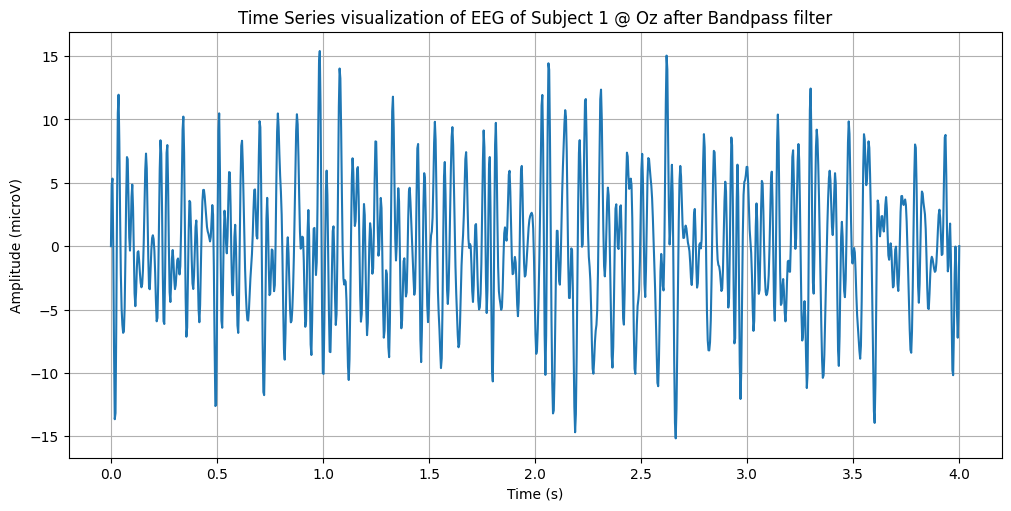

In [48]:
fig, ax = plt.subplots(figsize= (10,5), sharex=True, sharey=True, layout="constrained")
ax.plot(np.linspace(0, 4, 1114),subject1data[1].get_data()[1,7,:])
ax.grid(True)
ax.set_title("Time Series visualization of EEG of Subject 1 @ Oz after Bandpass filter")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (microV)")

CCA Preprocessing

In [49]:
time_series_mean = []
for target_data in subject1data:
    time_series_mean.append(np.mean(target_data.get_data(), 2))

print(np.mean(time_series_mean)) #is around 0, so i hope we dont have to center it :)

0.012119744105809826


Generating Refernece matrix (freq x sin/cos row x harmonics x freq)

In [40]:
harmonics = np.arange(1,4)
times = np.linspace(t_min, t_max, n_points)

Y = np.zeros([n_targets,1, 2*len(harmonics), n_points])
for k, freq in enumerate(stim_freq):
    Y[k,:,:] = [[[np.sin(2*np.pi*h*freq*time) for time in times] for h in harmonics] + [[np.cos(2*np.pi*h*freq*time) for time in times] for h in harmonics]]

print(np.shape(Y))

(12, 1, 6, 1114)


Computing Covaraiance Matrices

In [41]:
C_XX = [
    (data.get_data() @ data.get_data().transpose(0,2,1))/n_points for data in subject1data
] # Channel x Channel Covariance matrix (Auto Covariance on EEG

C_YY = [
    np.squeeze(data) @ np.squeeze(data).T/n_points for data in Y
]

C_XY = [
    subject1data[k].get_data() @ np.squeeze(Y[k].T)/n_points for k in range(n_targets)
]
print("Shape of Auto Covariance of Reference:",np.shape(C_YY))
print("Shape of Auto Covariances of EEG data:", np.shape(C_XX))
print("Shape of Cross Covariance is:",np.shape(C_XY))

Shape of Auto Covariance of Reference: (12, 6, 6)
Shape of Auto Covariances of EEG data: (12, 15, 8, 8)
Shape of Cross Covariance is: (12, 15, 8, 6)


Computing Pearson's Coeff

A = inv(C_xx) * C_xy * inv(C_yy) * C_yx

In [42]:
C_XX = np.array(C_XX)
C_YY = np.array(C_YY) 
C_XY = np.array(C_XY)

inv_CXX = np.linalg.pinv(C_XX) 
inv_CYY = np.linalg.pinv(C_YY[:, np.newaxis, :, :])  # type: ignore
C_YX = C_XY.transpose(0, 1, 3, 2) # type: ignore

A = inv_CXX @ C_XY @ inv_CYY @ C_YX
print(A.shape)

(12, 15, 8, 8)


Finding Eigenvalues

In [43]:
eigvals = np.linalg.eigvals(A)
print(np.shape(eigvals))

(12, 15, 8)


prediction

In [44]:
rho = np.sqrt(np.maximum(eigvals.real.max(axis=-1), 0)) # type: ignore
predictions = np.argmax(rho, axis = 0)
print(predictions)

[ 4  4  9 11  7  0  1  1  1 11 10  6  3  1  4]


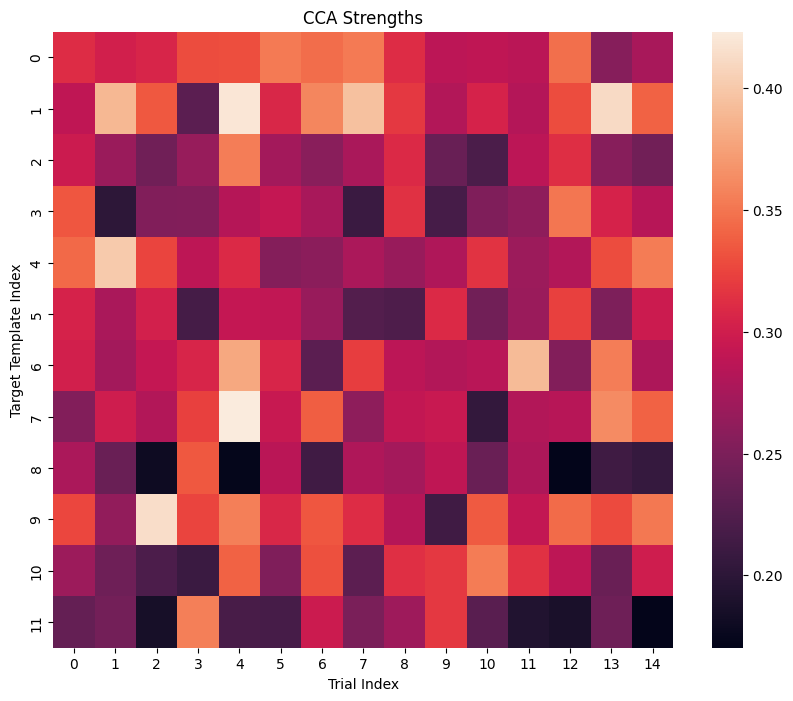

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(rho)
plt.xlabel("Trial Index")
plt.ylabel("Target Template Index")
plt.title("CCA Strengths")
plt.show()

[9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]


In [50]:
# Assuming your predictions array is of size 15 (one for each trial)
# And assuming all 15 trials were recorded while looking at target 'k'

# 1. Define your ground truth (the actual index of the target stimulus)
# For example, if these trials are from target 0:
ground_truth = np.zeros(15) 

# 2. Calculate accuracy
correct_predictions = np.sum(predictions == ground_truth)
accuracy = (correct_predictions / len(predictions)) * 100

print(f"Total Trials: {len(predictions)}")
print(f"Correct: {correct_predictions}")
print(f"Accuracy: {accuracy:.2f}%")

# 3. See the mistakes
for i, pred in enumerate(predictions):
    if pred != ground_truth[i]:
        print(f"Trial {i}: Predicted {stim_freq[int(pred)]}Hz, but was {stim_freq[int(ground_truth[i])]}Hz")

Total Trials: 15
Correct: 1
Accuracy: 6.67%
Trial 0: Predicted 11.75Hz, but was 9.25Hz
Trial 1: Predicted 11.75Hz, but was 9.25Hz
Trial 2: Predicted 10.75Hz, but was 9.25Hz
Trial 3: Predicted 14.75Hz, but was 9.25Hz
Trial 4: Predicted 12.25Hz, but was 9.25Hz
Trial 6: Predicted 11.25Hz, but was 9.25Hz
Trial 7: Predicted 11.25Hz, but was 9.25Hz
Trial 8: Predicted 11.25Hz, but was 9.25Hz
Trial 9: Predicted 14.75Hz, but was 9.25Hz
Trial 10: Predicted 12.75Hz, but was 9.25Hz
Trial 11: Predicted 10.25Hz, but was 9.25Hz
Trial 12: Predicted 9.75Hz, but was 9.25Hz
Trial 13: Predicted 11.25Hz, but was 9.25Hz
Trial 14: Predicted 11.75Hz, but was 9.25Hz


Visualizing Covariance Matrices

In [ ]:
row = 12
col = 15

fig, axes = plt.subplots(row, col, figsize = (1.25*row, 1.25*col), layout = "constrained", sharex = True, sharey = True)
for t in range(row):
    for tr in range(col):
        sns.heatmap(C_XX[t][tr], cmap ='viridis', ax = axes[t][tr], cbar=False)
        axes[t][tr].set_title(f"{stim_freq[t]}, {tr}")